<a href="https://colab.research.google.com/github/dspraneeth07/CognitiveAttackTopology-CAT/blob/main/Notebooks/10_intervention_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Run: 20260307_122529
TPS: 0.13447908558318653
Notebook 10 completed


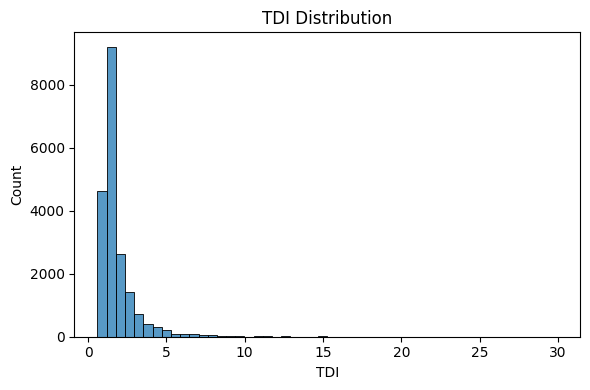

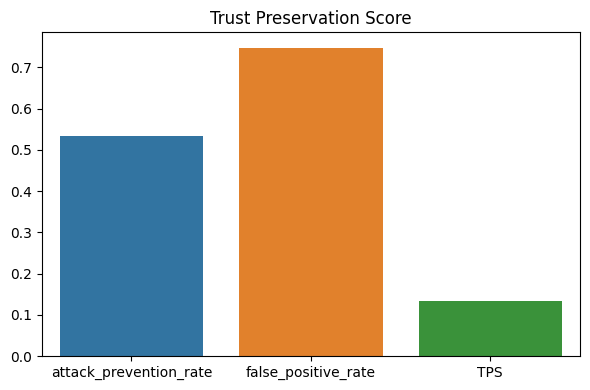

In [2]:
# ===============================================================
# NOTEBOOK 10 — INTERVENTION SIMULATION
# CAT Framework
# CPU SAFE IMPLEMENTATION
# ===============================================================

!pip -q install pandas numpy seaborn matplotlib pyarrow

import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from google.colab import drive

# ===============================================================
# MOUNT DRIVE
# ===============================================================

drive.mount('/content/drive', force_remount=True)

ROOT = Path("/content/drive/MyDrive/CAT_RESEARCH")

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = ROOT/"runs"/RUN_ID
DATA_DIR = ROOT/"data"

REPORT_DIR = RUN_DIR/"reports"
PLOT_DIR = RUN_DIR/"plots"

for p in [RUN_DIR, REPORT_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Run:",RUN_ID)

# ===============================================================
# LOAD DATASET
# ===============================================================

df = pd.read_parquet(DATA_DIR/"GCT_phase1_100k.parquet")

# sample subset for fast simulation
df = df.sample(20000, random_state=42)

# ===============================================================
# TRUST DISTORTION INDEX (FAST CALC)
# ===============================================================

trust = df[[
"urgency_score",
"fear_trigger_score",
"authority_claim",
"trust_manipulation_score"
]].values

sigma = trust.std(axis=1)

sigma[sigma==0] = 1e-6

CDE = trust.mean(axis=1)

TDI = CDE / sigma

df["TDI"] = TDI

# ===============================================================
# INTERVENTION POLICY
# ===============================================================

call_warning_threshold = 1.2
otp_block_threshold = 1.5
phishing_block_threshold = 1.8

def classify_intervention(tdi):

    if tdi > phishing_block_threshold:
        return "phishing_block"

    elif tdi > otp_block_threshold:
        return "otp_block"

    elif tdi > call_warning_threshold:
        return "call_warning"

    else:
        return "no_action"

df["intervention"] = df["TDI"].apply(classify_intervention)

# ===============================================================
# USER BEHAVIOR MODEL
# ===============================================================

np.random.seed(42)

# probability user obeys warning
compliance_prob = 0.7

df["user_complies"] = np.random.rand(len(df)) < compliance_prob

# ===============================================================
# ATTACK PREVENTION SIMULATION
# ===============================================================

attack = df["human_verified_label"] == 1

prevented = (
attack &
(df["intervention"] != "no_action") &
df["user_complies"]
)

df["attack_prevented"] = prevented

attack_prevention_rate = prevented.sum() / attack.sum()

# ===============================================================
# FALSE POSITIVES
# ===============================================================

legit = df["human_verified_label"] == 0

false_block = (
legit &
(df["intervention"] != "no_action")
)

false_positive_rate = false_block.sum() / legit.sum()

# ===============================================================
# TRUST PRESERVATION SCORE
# ===============================================================

TPS = attack_prevention_rate * (1 - false_positive_rate)

tps_df = pd.DataFrame({

"attack_prevention_rate":[attack_prevention_rate],
"false_positive_rate":[false_positive_rate],
"TPS":[TPS]

})

tps_df.to_csv(REPORT_DIR/"trust_preservation_scores.csv",index=False)

print("TPS:",TPS)

# ===============================================================
# INTERVENTION SCENARIO ANALYSIS
# ===============================================================

scenario_counts = df["intervention"].value_counts()

scenario_counts.to_csv(REPORT_DIR/"intervention_simulation_results.csv")

# ===============================================================
# FALSE POSITIVE IMPACT
# ===============================================================

false_df = pd.DataFrame({

"false_positive_rate":[false_positive_rate],
"legit_blocked":[false_block.sum()],
"total_legit":[legit.sum()]

})

false_df.to_csv(REPORT_DIR/"false_positive_impact_analysis.csv",index=False)

# ===============================================================
# ATTACK PREVENTION METRICS
# ===============================================================

attack_df = pd.DataFrame({

"attack_prevented":[prevented.sum()],
"total_attacks":[attack.sum()],
"attack_prevention_rate":[attack_prevention_rate]

})

attack_df.to_csv(REPORT_DIR/"attack_prevention_metrics.csv",index=False)

# ===============================================================
# POLICY COMPARISON (AGGRESSIVE VS CONSERVATIVE)
# ===============================================================

df["aggressive"] = df["TDI"] > 1.0
df["conservative"] = df["TDI"] > 1.6

policy = pd.DataFrame({

"policy":["aggressive","conservative"],

"blocked":[
df["aggressive"].sum(),
df["conservative"].sum()
]

})

policy.to_csv(REPORT_DIR/"intervention_policy_comparison.csv",index=False)

# ===============================================================
# VISUALIZATION
# ===============================================================

plt.figure(figsize=(6,4))

sns.histplot(df["TDI"],bins=50)

plt.title("TDI Distribution")

plt.tight_layout()

plt.savefig(PLOT_DIR/"tdi_distribution.png")

# ===============================================================
# TPS VISUALIZATION
# ===============================================================

plt.figure(figsize=(6,4))

sns.barplot(data=tps_df)

plt.title("Trust Preservation Score")

plt.tight_layout()

plt.savefig(PLOT_DIR/"tps_score.png")

# ===============================================================
# FINAL REPORT
# ===============================================================

report = {

"TPS":float(TPS),
"attack_prevention_rate":float(attack_prevention_rate),
"false_positive_rate":float(false_positive_rate)

}

with open(REPORT_DIR/"intervention_evaluation_report.json","w") as f:

    json.dump(report,f,indent=4)

print("Notebook 10 completed")